Parses code directly from randomcircuit_indep_opt3_13.qasm. May need to `pip install qiskit_qasm3_import` first. Can't quite do the same for dj_indep_opt0_130.qasm as it is too many qubits to transpile.

In [50]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Gate
from math import pi

In [51]:
def csdg():
    qc = QuantumCircuit(2, name="csdg")
    qc.tdg(0)
    qc.cx(0, 1)
    qc.t(1)
    qc.cx(0, 1)
    qc.tdg(1)
    return qc.to_gate()

def rccx():
    qc = QuantumCircuit(3, name="rccx")
    qc.h(2)
    qc.t(2)
    qc.cx(1, 2)
    qc.tdg(2)
    qc.cx(0, 2)
    qc.t(2)
    qc.cx(1, 2)
    qc.tdg(2)
    qc.h(2)
    return qc.to_gate()

def ccz():
    qc = QuantumCircuit(3, name="ccz")
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    return qc.to_gate()

def ecr():
    qc = QuantumCircuit(2, name="ecr")
    qc.s(0)
    qc.sx(1)
    qc.cx(0, 1)
    qc.x(0)
    return qc.to_gate()

def rcccx():
    qc = QuantumCircuit(4, name="rcccx")
    qc.h(3)
    qc.t(3)
    qc.cx(2, 3)
    qc.tdg(3)
    qc.h(3)
    qc.cx(0, 3)
    qc.t(3)
    qc.cx(1, 3)
    qc.tdg(3)
    qc.cx(0, 3)
    qc.t(3)
    qc.cx(1, 3)
    qc.tdg(3)
    qc.h(3)
    qc.t(3)
    qc.cx(2, 3)
    qc.tdg(3)
    qc.h(3)
    return qc.to_gate()

def r(p0,p1):
    qc = QuantumCircuit(1, name = "r")
    qc.u(p0, -pi/2 + p1, pi/2 - p1, 1)
    return qc.to_gate()

def c3sx():
    qc = QuantumCircuit(4, name="c3sx")
    qc.h(3)
    qc.cp(pi/8,0,3)
    qc.h(3)
    qc.cx(0,1)
    qc.h(3)
    qc.cp(-pi/8,1,3)
    qc.h(3)
    qc.cx(0,1)
    qc.h(3)
    qc.cp(pi/8,1,3)
    qc.h(3)
    qc.cx(1,2)
    qc.h(3)
    qc.cp(-pi/8,2,3)
    qc.h(3)
    qc.cx(0,2)
    qc.h(3)
    qc.cp(pi/8,2,3)
    qc.h(3)
    qc.cx(1,2)
    qc.h(3)
    qc.cp(-pi/8,2,3)
    qc.h(3)
    qc.cx(0,2)
    qc.h(3)
    qc.cp(pi/8,2,3)
    qc.h(3)
    return qc.to_gate()

def sxdg():
    qc = QuantumCircuit(1, name="sxdg")
    qc.s(0)
    qc.h(0)
    qc.s(0)
    return qc.to_gate()

def xx_plus_yy(p0,p1):
    qc = QuantumCircuit(2, name="xx_plus_yy")
    qc.rz(p1,0)
    qc.sdg(1)
    qc.sx(1)
    qc.s(1)
    qc.s(0)
    qc.cx(1,0)
    qc.ry(-0.5*p0,1)
    qc.ry(-0.5*p0,0)
    qc.cx(1,0)
    qc.sdg(0)
    qc.sdg(1)
    qc.sxdg(1)
    qc.s(1)
    qc.rz(-p1, 0)
    return qc.to_gate()

def iswap():
    qc = QuantumCircuit(2, name="iswap")
    qc.s(0)
    qc.s(1)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 0)
    qc.h(1)
    return qc.to_gate()

In [52]:
q = QuantumRegister(13, 'q')
c = ClassicalRegister(13, 'c')
qc = QuantumCircuit(q, c)

In [53]:
# instantiate reusable gates
csdg_gate = csdg()
rccx_gate = rccx()
ccz_gate = ccz()
ecr_gate = ecr()
rcccx_gate = rcccx()
sxdg_gate = sxdg()
iswap_gate = iswap()
c3sx_gate = c3sx()

qc.u(2.405358320221107, -2.204901315398946, -0.23521883274038657, q[2])
qc.ccx(q[6], q[1], q[4])
qc.cswap(q[10], q[9], q[7])
qc.append(csdg_gate, [q[7], q[1]])
qc.append(rccx_gate, [q[8], q[11], q[0]])
qc.cz(q[8], q[9])
qc.append(ccz_gate, [q[3], q[5], q[12]])
qc.cswap(q[5], q[11], q[6])
qc.sdg(q[6])
qc.append(ccz_gate, [q[10], q[3], q[0]])
qc.ch(q[9], q[0])
qc.append(ccz_gate, [q[10], q[5], q[8]])
qc.append(ecr_gate, [q[12], q[4]])
qc.append(rccx_gate, [q[1], q[11], q[12]])
qc.append(ccz_gate, [q[1], q[9], q[11]])
qc.append(rcccx_gate, [q[4], q[3], q[2], q[7]])
qc.cy(q[0], q[7])
qc.append(ccz_gate, [q[2], q[4], q[5]])
qc.p(2.2426295156381317, q[4])
qc.append(csdg_gate, [q[6], q[12]])
qc.crz(2.401193884234052, q[7], q[2])
qc.ccx(q[8], q[10], q[3])
qc.append(rccx_gate, [q[0], q[11], q[8]])
qc.sdg(q[0])
qc.append(ccz_gate, [q[1], q[3], q[6]])
qc.append(ccz_gate, [q[9], q[12], q[5]])
qc.ccx(q[4], q[8], q[9])
qc.y(q[4])
qc.cz(q[5], q[3])
qc.cy(q[8], q[3])
qc.t(q[8])

#qc.append(r(0.9052373921267518,5.087406807216837), [q[10]])
qc.u(0.9052373921267518, -pi/2 + 5.087406807216837, pi/2 - 5.087406807216837, q[10])

qc.append(ccz_gate, [q[2], q[10], q[6]])
qc.append(rcccx_gate, [q[11], q[7], q[12], q[1]])

qc.append(c3sx_gate, [q[5], q[10], q[7], q[2]])

qc.t(q[5])
qc.cswap(q[9], q[1], q[0])
qc.sx(q[9])
qc.append(rccx_gate, [q[11], q[12], q[6]])
qc.append(rccx_gate, [q[1], q[2], q[6]])
qc.ccx(q[5], q[10], q[6])
qc.cswap(q[9], q[8], q[1])
qc.append(rccx_gate, [q[6], q[9], q[5]])
qc.append(ccz_gate, [q[11], q[0], q[3]])
qc.cx(q[3], q[0])

qc.append(xx_plus_yy(3.650842432466433, 0.7871534634082653),[q[11], q[2]])
#qc.append( xx_plus_yy(3.650842432466433, 0.7871534634082653).to_instruction(), [q[11], q[2]])

qc.append(rccx_gate, [q[10], q[11], q[8]])
qc.append(rccx_gate, [q[12], q[4], q[7]])
qc.append(ccz_gate, [q[4], q[7], q[12]])
qc.append(rcccx_gate, [q[2], q[1], q[12], q[7]])
qc.tdg(q[1])
qc.t(q[2])
qc.ccx(q[3], q[0], q[4])
qc.append(ccz_gate, [q[3], q[4], q[10]])
qc.append(ccz_gate, [q[9], q[6], q[0]])
qc.cswap(q[9], q[4], q[0])
qc.u(0.8989729695019022, 2.836148587154802, 2.833584415720613, q[0])
qc.append(rcccx_gate, [q[11], q[7], q[5], q[8]])
qc.append(iswap_gate, [q[2], q[8]])
qc.ccx(q[7], q[1], q[5])
qc.p(4.9769972339930675, q[7])
qc.t(q[11])
qc.append(ccz_gate, [q[5], q[1], q[11]])
qc.s(q[12])
qc.append(rcccx_gate, [q[6], q[3], q[12], q[10]])
qc.append(ccz_gate, [q[8], q[2], q[10]])
qc.append(ccz_gate, [q[4], q[8], q[11]])
qc.append(rccx_gate, [q[9], q[8], q[2]])
qc.ccx(q[12], q[6], q[3])

qc.append(c3sx_gate, [q[1], q[10], q[6], q[7]])

qc.cswap(q[0], q[11], q[1])
qc.cswap(q[10], q[6], q[4])

# qc.append(r(4.293549040632536, 5.7319921890492616), [q[4]])
qc.u(4.293549040632536, -pi/2 + 5.7319921890492616, pi/2 - 5.7319921890492616, q[4])

qc.crz(2.115194114548841, q[6], q[10])
qc.append(rccx_gate, [q[12], q[5], q[3]])
qc.append(ccz_gate, [q[3], q[5], q[12]])
qc.ccx(q[1], q[11], q[5])
qc.cswap(q[3], q[0], q[7])
qc.sx(q[0])
qc.append(rccx_gate, [q[6], q[4], q[5]])

qc.append(c3sx_gate, [q[9], q[12], q[8], q[2]])

qc.ccx(q[2], q[9], q[8])
qc.cz(q[0], q[9])
qc.u(3.568967231508171, 5.468967898137674, 5.6946507737984255, q[8])
qc.append(ccz_gate, [q[11], q[7], q[3]])
qc.append(ccz_gate, [q[2], q[7], q[6]])
qc.ccx(q[6], q[8], q[7])
qc.cswap(q[2], q[7], q[6])
qc.t(q[11])
qc.cswap(q[12], q[10], q[1])
qc.ccx(q[4], q[1], q[10])
qc.cry(3.8194794471039017, q[1], q[10])
qc.append(ccz_gate, [q[12], q[3], q[5]])
qc.sx(q[5])
qc.cswap(q[9], q[3], q[4])
qc.append(rccx_gate, [q[11], q[0], q[12]])
qc.append(ccz_gate, [q[8], q[0], q[5]])
qc.append(csdg_gate, [q[7], q[5]])
qc.append(rccx_gate, [q[9], q[12], q[1]])
qc.ccx(q[0], q[1], q[12])
qc.z(q[9])
qc.cswap(q[11], q[10], q[4])

qc.append(c3sx_gate, [q[10], q[4], q[3], q[8]])

qc.ch(q[8], q[3])
qc.u(pi/2, -pi/2, 0.7223617177699095, q[3]) #U vs u vs u2?
qc.ccx(q[11], q[2], q[6])
qc.ccx(q[6], q[9], q[4])
qc.cswap(q[10], q[7], q[2])
qc.u(pi/2, 1.4073080668162754, 0.28133025188542254, q[11])
qc.append(rccx_gate, [q[12], q[5], q[1]])

qc.append(c3sx_gate, [q[1], q[8], q[0], q[9]])

qc.ccx(q[5], q[6], q[11])
qc.append(ccz_gate, [q[6], q[1], q[0]])
qc.u(pi/2, 5.56747622367805, 2.1140484731424545, q[6])
qc.append(ccz_gate, [q[11], q[8], q[7]])
qc.cx(q[1], q[8])
qc.append(rccx_gate, [q[12], q[10], q[2]])
qc.u(0.2449755639009652, 1.632717464139418, 3.10743595974429, q[2])

qc.append(c3sx_gate, [q[4], q[5], q[9], q[10]])

qc.append(rccx_gate, [q[7], q[4], q[11]])
qc.append(ccz_gate, [q[2], q[1], q[11]])
qc.ccx(q[9], q[3], q[5])
qc.append(rccx_gate, [q[4], q[9], q[3]])
qc.append(rccx_gate, [q[7], q[8], q[5]])
qc.rx(5.514100154870899, q[12])
qc.append(rccx_gate, [q[0], q[12], q[10]])
qc.sx(q[0])
qc.tdg(q[12])

qc.barrier()

for i in range(13):
    qc.measure(q[i], c[i])
# --- END ---

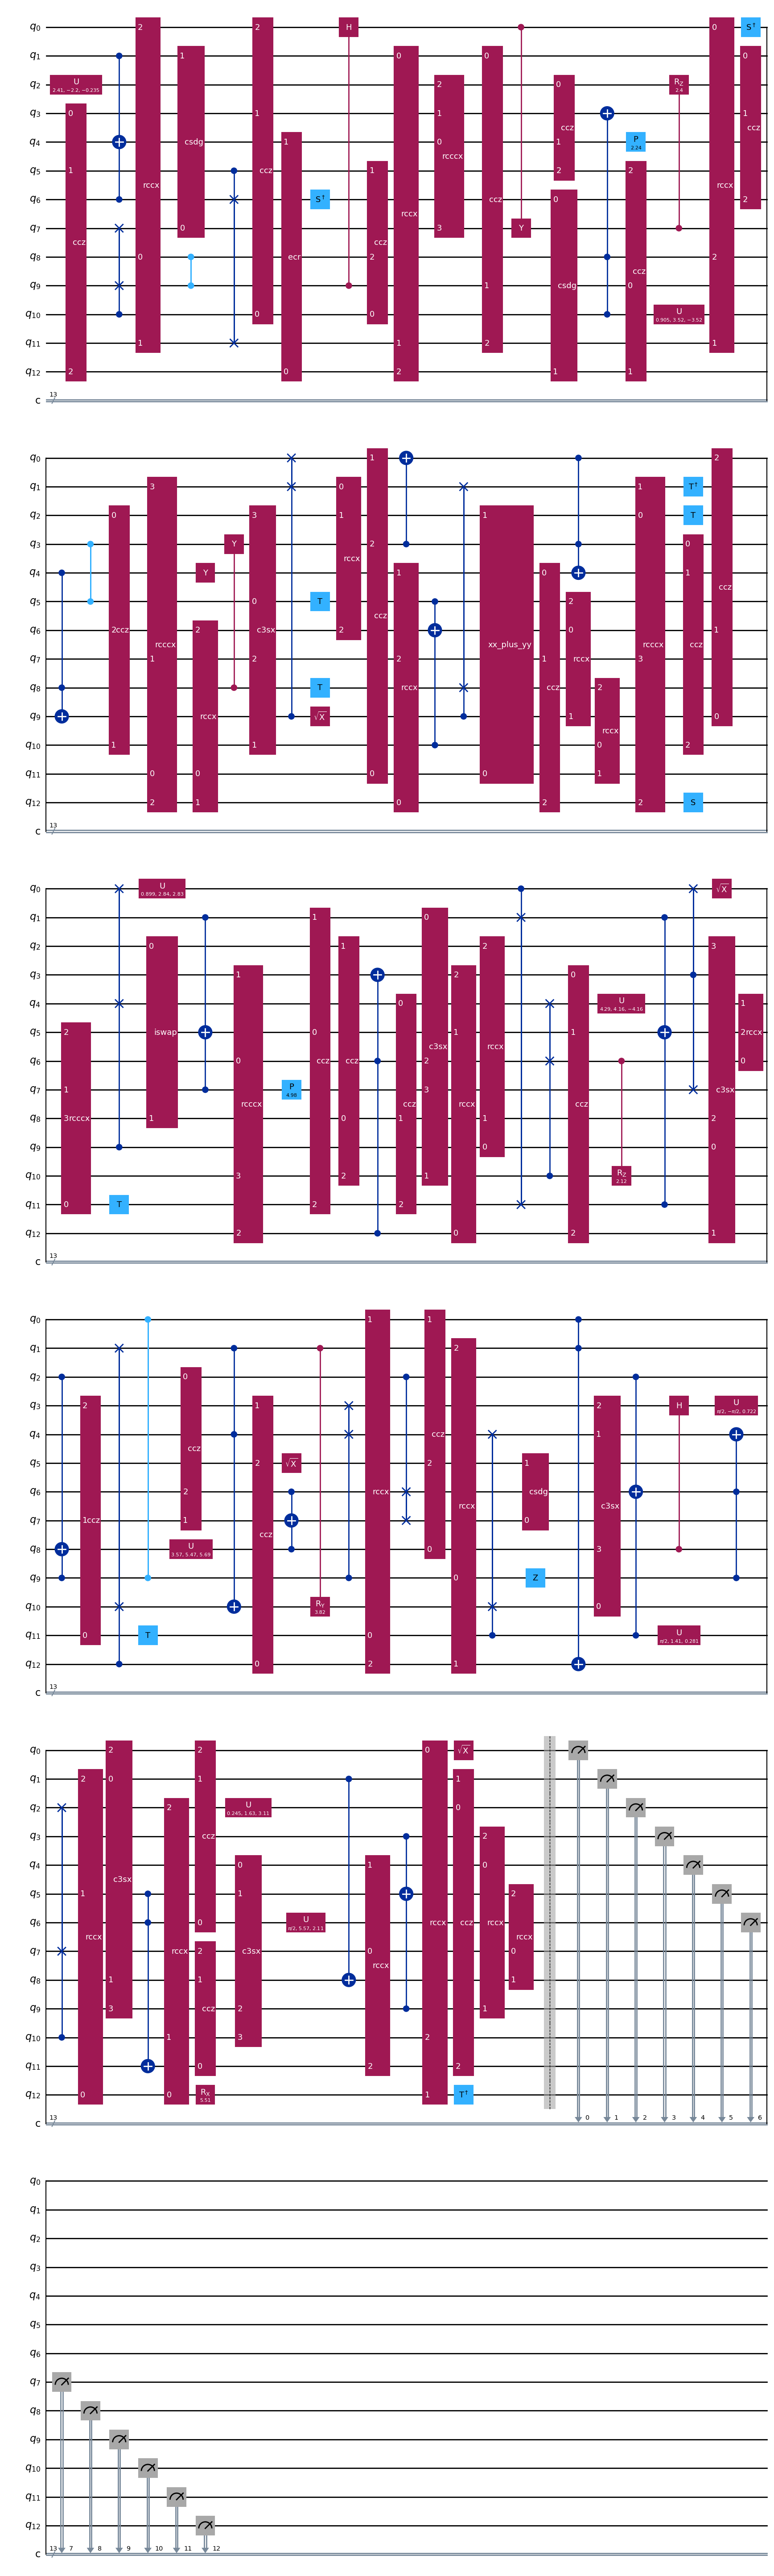

In [54]:
qc.draw('mpl')

In [55]:
print(qc.parameters)

ParameterView([])


In [56]:
from qiskit_aer import AerSimulator
from qiskit import transpile

sim = AerSimulator()
qc = qc.decompose()
qc_t = transpile(qc, sim)
result = sim.run(qc_t, shots=100).result()
print(result.get_counts())

{'1110101011001': 1, '1111100001000': 1, '1001001100000': 1, '1101110000110': 1, '0111100111111': 1, '1101000101011': 1, '0001100000001': 2, '0101111001001': 1, '1101000100110': 1, '1101000011100': 1, '1101100001001': 1, '1110000101011': 2, '1011001101010': 2, '0011101001001': 1, '1000111101000': 1, '1101100001000': 1, '0011001001110': 1, '1101110110110': 1, '1010100011000': 1, '0011001000111': 1, '1111000101010': 1, '0000011000010': 1, '0110001000000': 1, '0101100101001': 1, '0101011010111': 1, '1111001101011': 1, '1101100001110': 1, '1000101101001': 1, '0101100001000': 1, '0110101101100': 1, '0001011100010': 1, '1001001010010': 1, '0001111000011': 1, '1111101000111': 1, '1000100000001': 1, '0001101100001': 1, '0000111101001': 1, '1000101011000': 1, '1001100001111': 1, '1101001101010': 1, '1001111101001': 2, '0101101000000': 1, '1100000011010': 1, '0100100111100': 1, '0001100101101': 1, '0101101101001': 1, '1010111001000': 1, '1101010101110': 1, '0101000101000': 1, '1000001100010': 1,